<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week6/Day1/ExerciseXP/Exercises_XP_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Introduction to LLMs

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells containing **TODO** markers need your input.


## 👩‍🏫👩🏿‍🏫 What you’ll learn
- Understand what Large Language Models (LLMs) can do.
- Review the Transformer architecture and the tokenization pipeline.
- Differentiate between pretraining and fine-tuning.
- Generate text with a pretrained language model.


## 🛠️ What you will create
- Markdown answers describing key NLP concepts.
- Python code that loads GPT-2 (or a similar causal LM) and performs basic tokenization and generation.


> **Learning point**
> Work through the exercises sequentially. Run installation cells only once, then focus on filling each TODO before executing the corresponding code.


## 🌟 Exercise 1 · What are Large Language Models?


### 1.1 Define LLMs
Large Language Models (LLMs) are deep learning algorithms trained on massive datasets of text to understand, summarize, translate, and generate human-like language. They are designed to solve a wide variety of natural language processing tasks, including content generation, question answering, semantic search, sentiment analysis, and code synthesis by predicting the most probable next token in a sequence based on the context provided.


### 1.2 Prefilled · install core libraries
Run once to install `transformers`, `torch`, and supporting utilities exactly as in the enoncé.


In [1]:
%pip install --quiet transformers matplotlib --upgrade


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 15.6 MB/s eta 0:00:00


### 1.3 Load GPT for causal text generation
Reuse the snippet from the platform: declare the model name, tokenizer, and model weights.


In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

model_name = 'gpt2'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

if None in (model_name, tokenizer, model):
    raise ValueError("Fill in model_name, tokenizer, and model before continuing.")

print(f"\nModel '{model_name}' loaded successfully!")
print("""
GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.
""")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Model 'gpt2' loaded successfully!

GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.



## 🌟 Exercise 2 · Transformer Architecture and Tokenization


Tokenization is the process of breaking down raw text strings into smaller, manageable units called tokens, which can be whole words, subwords, or individual characters. Since neural networks cannot process text directly, this step is essential to map each textual fragment to a unique numerical index (Token ID) within the vocabulary, allowing the model to perform mathematical operations on the input sequence.


Original Text: Artificial intelligence changes the world step by step.
Tokens: ['Art', 'ificial', 'Ġintelligence', 'Ġchanges', 'Ġthe', 'Ġworld', 'Ġstep', 'Ġby', 'Ġstep', '.']
Token IDs: [8001, 9542, 4430, 2458, 262, 995, 2239, 416, 2239, 13]


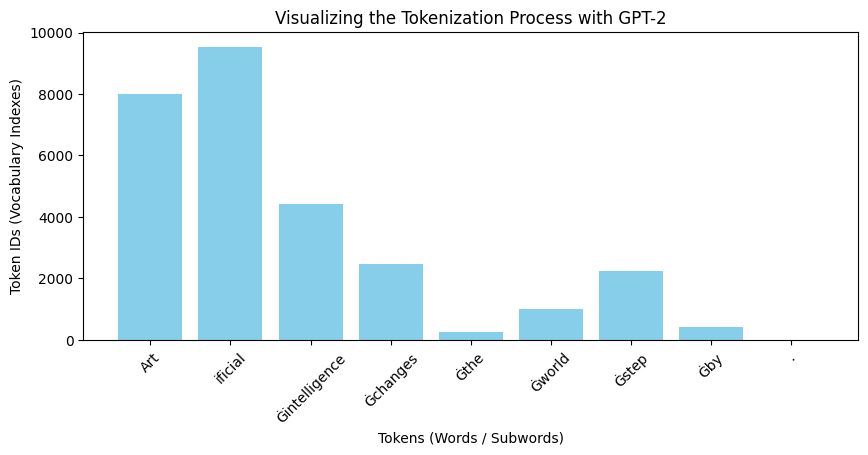

In [3]:
text = "Artificial intelligence changes the world step by step."
if text is None:
    raise ValueError("Define the variable `text` with a short sentence.")

tokens = tokenizer.tokenize(text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print(f"Original Text: {text}")
print(f"Tokens: {tokens}")
print(f"Token IDs: {token_ids}")

x_label = "Tokens (Words / Subwords)"
y_label = "Token IDs (Vocabulary Indexes)"
title = "Visualizing the Tokenization Process with GPT-2"

if None in (x_label, y_label, title):
    raise ValueError("Set x_label, y_label, and title before plotting.")

plt.figure(figsize=(10, 4))
plt.bar(tokens, token_ids, color="skyblue")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(rotation=45)
plt.show()


## 🌟 Exercise 3 · Token IDs and special prefixes


In [4]:
if 'tokens' not in globals() or 'token_ids' not in globals():
    raise ValueError("Run Exercise 2 to define `tokens` and `token_ids` first.")

# Print the token along with its numeric id
for tok, tok_id in zip(tokens, token_ids):
    print(f"Token: {tok:15} -> ID: {tok_id}")


Token: Art             -> ID: 8001
Token: ificial         -> ID: 9542
Token: Ġintelligence   -> ID: 4430
Token: Ġchanges        -> ID: 2458
Token: Ġthe            -> ID: 262
Token: Ġworld          -> ID: 995
Token: Ġstep           -> ID: 2239
Token: Ġby             -> ID: 416
Token: Ġstep           -> ID: 2239
Token: .               -> ID: 13


In GPT-style vocabularies, the special prefix Ġ represents a leading space before a word or subword token. It is a visual artifact of the Byte-Pair Encoding (BPE) tokenizer used to represent whitespace characters natively as part of the token itself, allowing the model to distinguish between a word appearing at the very beginning of a sentence and the same word appearing mid-sentence preceded by a space, ensuring exact text reconstruction during decoding.

## 🌟 Exercise 4 · Generate simple text


Create a fresh prompt, run the generator, and observe how the model extends your sentence token by token.


In [5]:
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

input_text = "The future of deep learning will"
if input_text is None:
    raise ValueError("Set `input_text` before generating.")

gen_kwargs = {
    "max_new_tokens": 60,
    "temperature": 0.8,
    "top_p": 0.95,
    "do_sample": True,
}

output_ids = generator(input_text, **gen_kwargs)
output_text = output_ids[0]["generated_text"]

print(f"Input: {input_text}")
print(f"Generated Output: {output_text}")


[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature', 'top_p', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe

Input: The future of deep learning will
Generated Output: The future of deep learning will probably depend on how this approach plays out and how best to leverage it.

This post was originally published on AI.

Update: A note on the subject of deep learning, and how to use it for business.

It's always good to get a feel for how a problem


> **Learning point**
> Compare the generated continuation with your expectations. Which knobs (temperature, max tokens) change the style the most?


### Summary of LLM Generation Parameters

Based on the generation parameters, here is how to understand and tune these settings:

1. **Temperature**: This controls the randomness of the model's output. Setting it closer to 0 makes the text sharp, predictable, and focused on the highest-probability words (ideal for factual answers or code). Increasing it toward 1 or higher introduces more randomness and creativity, allowing the model to choose less predictable tokens.
2. **Top-p (Nucleus Sampling)**: This parameter limits the pool of potential tokens to a cumulative probability threshold (e.g., 0.95). It works alongside temperature to filter out completely irrelevant or highly unusual words, ensuring the text remains coherent even when the model is being creative.
3. **Max Tokens**: This defines a hard upper bound for the response length. It is essential for managing computational costs, reducing response latency, and preventing the model from running into endless loops or overrunning the context.


![image.png](https://github.com/user-attachments/assets/a4c444d7-fab8-4f56-b7c7-00a15900cb5a)